# 02 — Training Model KNN (3 Fitur: Accel + Gyro + BPM)

**Prasyarat:** Jalankan `01_eksplorasi_data.ipynb` terlebih dahulu.
File `data/processed/dataset_clean.csv` harus sudah tersedia.

**Sumber data:** Dataset dikumpulkan menggunakan `src/collect_participants.py`.
Label aktivitas (DUDUK/BERJALAN/BERLARI) diinput **manual oleh operator** per sesi,
bukan dari ESP32. ESP32 hanya mengirim data sensor mentah.


In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.preprocessing    import MinMaxScaler
from sklearn.metrics          import (accuracy_score, classification_report,
                                      confusion_matrix, ConfusionMatrixDisplay)

from config import (FEATURES, TARGET, CLASSES, CLASS_MAP, BPM_MED_PATH,
                    K_NEIGHBORS, KNN_METRIC, KNN_WEIGHTS, MODEL_PATH, SCALER_PATH)
from utils  import (load_and_clean_dataset, impute_bpm, normalize_features,
                    encode_labels, remove_outliers, get_logger)

logger = get_logger('notebook_02')
sns.set_theme(style='whitegrid')
print('Fitur yang digunakan:', FEATURES)

Fitur yang digunakan: ['accel_stddev', 'gyro_stddev', 'bpm_filled']


## 1. Muat Dataset Bersih

In [2]:
CLEAN_PATH = '../data/processed/dataset_clean.csv'
df_raw = load_and_clean_dataset(CLEAN_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Distribusi kelas:')
print(df_raw[TARGET].value_counts())

Shape: (4715, 8)
Distribusi kelas:
activity
DUDUK       2283
BERJALAN    1412
BERLARI     1020
Name: count, dtype: int64


## 2. Imputasi BPM = 0

BPM = 0 (sensor tidak terbaca) diisi median per kelas dari data training.

In [3]:
df, bpm_medians = impute_bpm(df_raw, fit=True)

# Simpan bpm_medians untuk server_knn.py
joblib.dump(bpm_medians, BPM_MED_PATH)
print('BPM medians disimpan:', BPM_MED_PATH)
print(bpm_medians)

# Hapus outlier
df = remove_outliers(df)
df = encode_labels(df)
print('Dataset setelah preprocessing:', df.shape)

BPM Median per kelas (untuk imputasi):
  DUDUK: 78 bpm
  BERJALAN: 90 bpm
  BERLARI: 103 bpm
  _global: 84 bpm
BPM medians disimpan: c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\bpm_medians.pkl
{'DUDUK': 78, 'BERJALAN': 90, 'BERLARI': 103, '_global': 84}
Dataset setelah preprocessing: (4570, 9)


## 3. Normalisasi 3 Fitur (accel_stddev, gyro_stddev, bpm_filled)

In [4]:
print('Sebelum normalisasi:')
print(df[FEATURES].describe().round(4))

df, scaler = normalize_features(df, fit=True)

print('\nSetelah normalisasi (min=0, max=1):')
print(df[FEATURES].describe().round(4))

Sebelum normalisasi:
       accel_stddev  gyro_stddev  bpm_filled
count     4570.0000    4570.0000   4570.0000
mean         0.0429      16.6545     89.0912
std          0.0586      20.1092     19.4437
min          0.0030       0.0226     31.0000
25%          0.0086       0.3459     75.0000
50%          0.0164       9.1628     83.0000
75%          0.0540      26.1484     98.0000
max          0.2889      88.2235    162.0000

Setelah normalisasi (min=0, max=1):
       accel_stddev  gyro_stddev  bpm_filled
count     4570.0000    4570.0000   4570.0000
mean         0.1395       0.1886      0.4434
std          0.2049       0.2280      0.1484
min          0.0000       0.0000      0.0000
25%          0.0196       0.0037      0.3359
50%          0.0467       0.1036      0.3969
75%          0.1782       0.2962      0.5115
max          1.0000       1.0000      1.0000


## 4. Split Train / Test

In [5]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
for cls in CLASSES:
    print(f'  {cls}: train={sum(y_train==cls)} test={sum(y_test==cls)}')

Train: 3656 | Test: 914


  DUDUK: train=1823 test=455
  BERJALAN: train=1122 test=281
  BERLARI: train=711 test=178


## 5. Hyperparameter Tuning — Cari K Terbaik

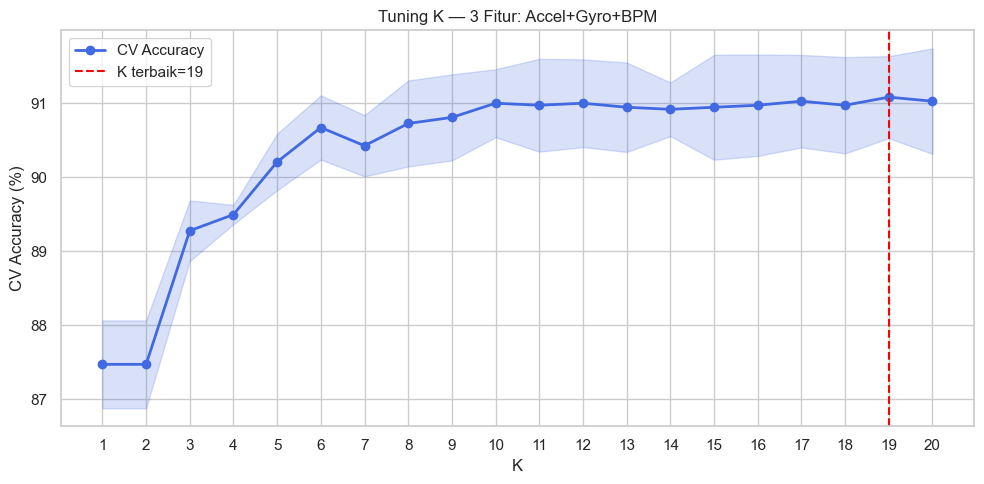

K terbaik: 19 (CV Acc = 91.08 %)


In [6]:
k_range   = range(1, 21)
cv_scores = []; cv_std = []
kfold     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric=KNN_METRIC, weights=KNN_WEIGHTS)
    scores = cross_val_score(knn, X_train, y_train, cv=kfold, scoring='accuracy')
    cv_scores.append(scores.mean()); cv_std.append(scores.std())

cv_scores = np.array(cv_scores); cv_std = np.array(cv_std)
best_k    = list(k_range)[np.argmax(cv_scores)]
best_score= cv_scores.max()

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), cv_scores*100, 'o-', color='royalblue', lw=2, label='CV Accuracy')
plt.fill_between(list(k_range), (cv_scores-cv_std)*100, (cv_scores+cv_std)*100,
                 alpha=0.2, color='royalblue')
plt.axvline(x=best_k, color='red', linestyle='--', label='K terbaik='+str(best_k))
plt.xlabel('K'); plt.ylabel('CV Accuracy (%)'); plt.legend()
plt.title('Tuning K — 3 Fitur: Accel+Gyro+BPM')
plt.xticks(list(k_range)); plt.tight_layout()
plt.savefig('../data/processed/tuning_k_3fitur.png', dpi=150); plt.show()
print('K terbaik:', best_k, '(CV Acc =', round(best_score*100,2), '%)')

## 6. Training Model Final

In [7]:
USE_K = best_k  # bisa override: USE_K = K_NEIGHBORS

knn = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print('K =', USE_K, '| Test Accuracy:', round(acc*100, 2), '%')

K = 19 | Test Accuracy: 91.68 %


## 7. Classification Report

In [8]:
print('=== CLASSIFICATION REPORT — 3 FITUR (Accel+Gyro+BPM) ===')
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

=== CLASSIFICATION REPORT — 3 FITUR (Accel+Gyro+BPM) ===
              precision    recall  f1-score   support

       DUDUK     0.8693    0.8754    0.8723       281
    BERJALAN     0.8811    0.9157    0.8981       178
     BERLARI     0.9619    0.9429    0.9523       455

    accuracy                         0.9168       914
   macro avg     0.9041    0.9113    0.9076       914
weighted avg     0.9177    0.9168    0.9171       914



## 8. Confusion Matrix

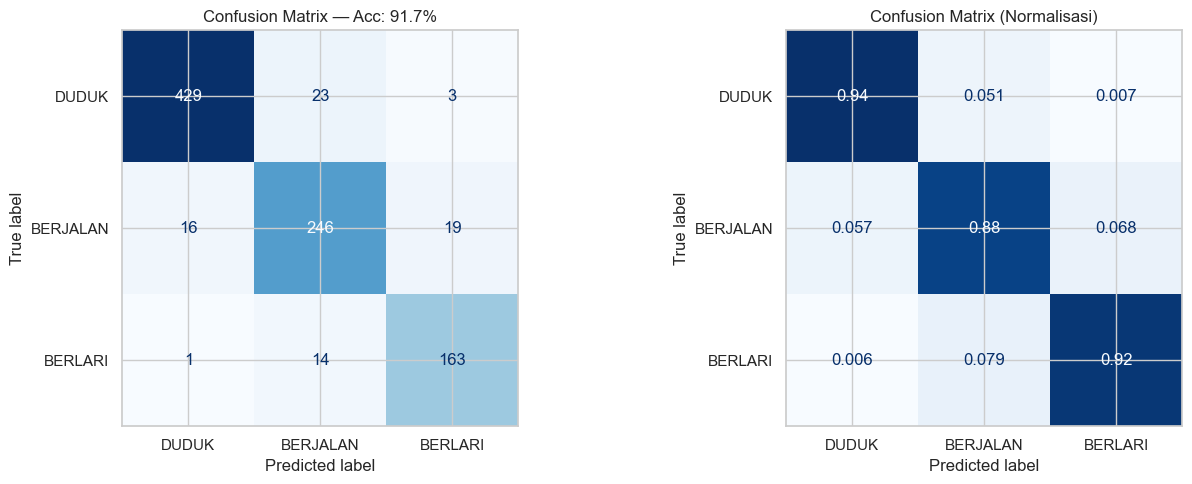

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Acc: ' + str(round(acc*100,1)) + '%')

cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(3), display_labels=CLASSES).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalisasi)')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_3fitur.png', dpi=150)
plt.show()

## 9. Kontribusi BPM — Bandingkan 2 vs 3 Fitur

=== PERBANDINGAN KOMBINASI FITUR ===
                   fitur       acc
Accel+Gyro+BPM (3 fitur) 91.684902
    Accel+Gyro (2 fitur) 90.590810
      BPM saja (1 fitur) 60.831510


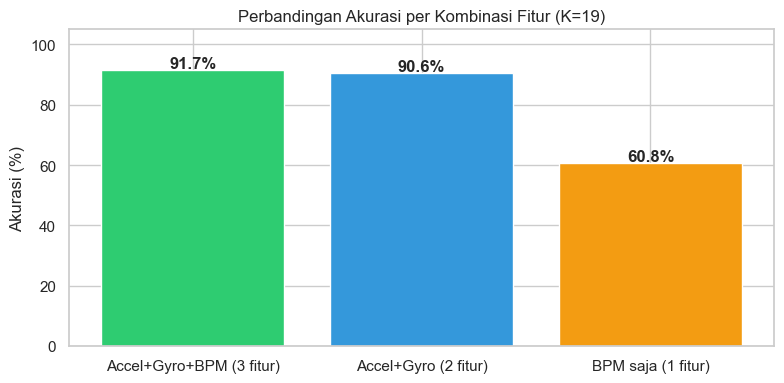


Penambahan BPM meningkatkan akurasi sebesar 1.09 %


In [10]:
results_feat = []

# 3 fitur
results_feat.append({'fitur': 'Accel+Gyro+BPM (3 fitur)', 'acc': acc*100})

# 2 fitur: Accel+Gyro
knn2 = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn2.fit(X_train[:, :2], y_train)
acc2 = accuracy_score(y_test, knn2.predict(X_test[:, :2]))
results_feat.append({'fitur': 'Accel+Gyro (2 fitur)', 'acc': acc2*100})

# BPM saja
knn_b = KNeighborsClassifier(n_neighbors=USE_K, metric=KNN_METRIC, weights=KNN_WEIGHTS)
knn_b.fit(X_train[:, 2:3], y_train)
acc_b = accuracy_score(y_test, knn_b.predict(X_test[:, 2:3]))
results_feat.append({'fitur': 'BPM saja (1 fitur)', 'acc': acc_b*100})

df_res = pd.DataFrame(results_feat).sort_values('acc', ascending=False)
print('=== PERBANDINGAN KOMBINASI FITUR ===')
print(df_res.to_string(index=False))

plt.figure(figsize=(8, 4))
bars = plt.bar(df_res['fitur'], df_res['acc'],
               color=['#2ecc71', '#3498db', '#f39c12'])
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi per Kombinasi Fitur (K=' + str(USE_K) + ')')
plt.ylim(0, 105)
for bar, val in zip(bars, df_res['acc']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             str(round(val,1))+'%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()

gain = acc*100 - acc2*100
print('\nPenambahan BPM meningkatkan akurasi sebesar', round(gain,2), '%')

## 10. Simpan Model, Scaler, BPM Medians

In [11]:
joblib.dump(knn,         MODEL_PATH)
joblib.dump(scaler,      SCALER_PATH)
joblib.dump(bpm_medians, BPM_MED_PATH)

print('Model  ->', MODEL_PATH)
print('Scaler ->', SCALER_PATH)
print('BPM    ->', BPM_MED_PATH)
print()
print('=== RINGKASAN MODEL ===')
print('Algoritma :', 'KNN')
print('K         :', USE_K)
print('Fitur     :', FEATURES)
print('BPM med   :', bpm_medians)
print('Test Acc  :', round(acc*100, 2), '%')

Model  -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\knn_model.pkl
Scaler -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\scaler.pkl
BPM    -> c:\Users\LENOVO\Desktop\Documents\folder kuliah\TA\iot\models\bpm_medians.pkl

=== RINGKASAN MODEL ===
Algoritma : KNN
K         : 19
Fitur     : ['accel_stddev', 'gyro_stddev', 'bpm_filled']
BPM med   : {'DUDUK': 78, 'BERJALAN': 90, 'BERLARI': 103, '_global': 84}
Test Acc  : 91.68 %


## 11. Perbandingan Metric Jarak (Opsional)

In [12]:
results = []
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    for w in ['uniform', 'distance']:
        knn_tmp = KNeighborsClassifier(n_neighbors=USE_K, metric=metric, weights=w)
        scores  = cross_val_score(knn_tmp, X_train, y_train, cv=kfold, scoring='accuracy')
        results.append({'metric':metric,'weights':w,
                         'cv_mean':round(scores.mean()*100,2),
                         'cv_std':round(scores.std()*100,2)})
df_m = pd.DataFrame(results).sort_values('cv_mean', ascending=False)
print('=== Perbandingan Konfigurasi KNN ===')
print(df_m.to_string(index=False))

=== Perbandingan Konfigurasi KNN ===
   metric  weights  cv_mean  cv_std
euclidean distance    91.08    0.55
manhattan distance    91.06    0.72
manhattan  uniform    90.97    0.54
chebyshev distance    90.89    0.35
euclidean  uniform    90.76    0.53
chebyshev  uniform    90.65    0.48
